In [1]:
from langgraph.graph import StateGraph, START , END 
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field
import operator
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate


In [2]:
load_dotenv()
llm = HuggingFaceEndpoint(
    # repo_id="meta-llama/Llama-3.1-8B-Instruct",  # Choose any model supporting Inference API
    repo_id = "Qwen/Qwen2.5-Coder-7B-Instruct",
    task="text-generation",
    max_new_tokens=512,
    do_sample=False,
    repetition_penalty=1.03,
    temperature=0.7,
)

# 2. Wrap with ChatHuggingFace
model = ChatHuggingFace(llm=llm, verbose=True)



d:\langgraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="sentiment of the review")
    

In [4]:

class DiagnosisSchema(BaseModel):
    issue_type : Literal["UX","Performance","Bug","Support","Other"]= Field(description="the category of the issue mentioned in the review")
    tone : Literal["Angry ","Frustrated","Disappointed","Calm"]=Field(description="emotional tone expressed by the user")
    urgency : Literal["Low","Medium","High"]= Field(description="How urgent or critical the issue appears to be")

# 2. Initialize Parser
parser = PydanticOutputParser(pydantic_object=DiagnosisSchema)


In [5]:
# review = "this phone is so bad . im so done with this phone "
# prompt = PromptTemplate(
#         template=(
#             "Diagnose this negative review:\n\n{review}\n\n"
#             "Return issue_type, tone, and urgency.\n"
#             "issue_type must be exactly one of: UX, Performance, Bug, Support, Other — never null, none, or empty.\n"
#             "tone must be exactly one of: Angry, Frustated, Disappointed, Calm.\n"
#             "urgency must be exactly one of: Low, Medium, High.\n"
#             "If unsure, pick the closest matching category — do not leave any field blank.\n\n"
#             "{format_instruction}"
#         ),

#         input_variables = ["review"],
#         partial_variables = {"format_instruction": parser.get_format_instructions()}
#     )
# chain = prompt | model | parser
# output = chain.invoke({'review':review})
# print(output)
# print(output.issue_type)

In [6]:
structured_model = model.with_structured_output(SentimentSchema,method="json_mode")


In [7]:

prompt = "what is the sentiment of the followig review return in this format {'sentiment':'positive'}or 'negative'- The software is too good"

output = structured_model.invoke(prompt)
output

{'sentiment': 'positive'}

In [8]:
class ReviewState(TypedDict):
    review : str 
    sentiment : Literal["positive","negative"]
    diagnosis : dict
    response : str 

In [9]:
def find_sentiment(state :ReviewState):
    prompt = f"for the following review find out the sentiment \n {state["review"]}"

    sentiment = structured_model.invoke(prompt)["sentiment"]
    return {'sentiment':sentiment}

def check_sentiment(state:ReviewState)->Literal["positive_response","run_diagnosis"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"

def positive_response(state:ReviewState):
    prompt = f"write a warm thank-you message in response to this review\n{state["review"]}\nAlso kindly ask the user to leave the feedback on our website"

    response = model.invoke(prompt).content
    return {'response':response}

def run_diagnosis(state:ReviewState):
    review = state["review"]
    prompt = PromptTemplate(
        template=(
            "Diagnose this negative review:\n\n{review}\n\n"
            "Return issue_type, tone, and urgency.\n"
            "issue_type must be exactly one of: UX, Performance, Bug, Support, Other — never null, none, or empty.\n"
            "tone must be exactly one of: Angry, Frustated, Disappointed, Calm.\n"
            "urgency must be exactly one of: Low, Medium, High.\n"
            "If unsure, pick the closest matching category — do not leave any field blank.\n\n"
            "{format_instruction}"
        ),

        input_variables = ["review"],
        partial_variables = {"format_instruction": parser.get_format_instructions()}
    )
    chain = prompt | model | parser
    output = chain.invoke({'review':review})

    return {"diagnosis":output.model_dump()}

def negative_response(state:ReviewState):

    diagnosis = state["diagnosis"]

    prompt= f"""you are a support assistant. The user had a {diagnosis["issue_type"]} issue , sounded {diagnosis["tone"]} , and marked urgency as {diagnosis["urgency"]}. Write a empathetic helpful resolution message"""

    response = model.invoke(prompt).content
    
    return {'response':response}

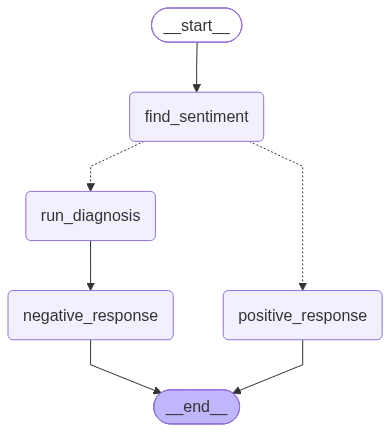

In [10]:
#define graph 
graph = StateGraph(ReviewState)

#define nodes 
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)
graph.add_node("positive_response",positive_response)



graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)



workflow = graph.compile()

workflow

In [11]:
# initial_state = {"review":"You know what , you have a knack of teaching in flow. I checked out many videos on these topics, langgraph , langchain . But , yours give us revision of the concepts and hence make them understand in better way. Awaiting videos on topics of advanced Langraph such as RAG/Agentic langgraph/ Multiagent flow."}

# workflow.invoke(initial_state)

initial_state = {"review": "This app keeps crashing every time I upload a file. Extremely frustrating and I need this fixed urgently."}
workflow.invoke(initial_state)

{'review': 'This app keeps crashing every time I upload a file. Extremely frustrating and I need this fixed urgently.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Frustrated', 'urgency': 'High'},
 'response': "Dear User,\n\nI am truly sorry to hear about the high-urgency bug you have been experiencing. I understand that this must be causing significant frustration for you and impacting your work.\n\nOur team is fully aware of the severity of this situation and we are working diligently to resolve it immediately. We value your patience and cooperation during this time and appreciate your detailed feedback on the issue so we can fix it more effectively.\n\nIf there's anything else I can do to help or provide updates, please don't hesitate to let us know. Thank you for bringing this matter to our attention.\n\nBest regards,\n[Your Name]\nSupport Assistant at [Company Name]"}